# Assignment Solution - Dimensionality Reduction with PCA and LDA

## **Lab Assignment 7: Eigenfaces**


<font color='gold'>Import Libraries </font>



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA as SKPCA
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Reproducibilityj
SEED = 42
np.random.seed(SEED)

### <font color='gold'> Task - 1 [Marks 1] </font>:
Load the Olivetti faces dataset from sklearn: (https://scikit-learn.org/0.19/modules/generated/sklearn.datasets.fetch_olivetti_faces.html#sklearn.datasets.fetch_olivetti_faces).

Display the shape of dataset, targets, number of classes and some images.

In [ ]:
data = fetch_olivetti_faces()
images = data.images        # shape (400, 64, 64)
targets = data.target       # shape (400,)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
print(f"Images shape: {images.shape}")
print(f"Targets shape: {targets.shape}")
print(f"Number of classes: {len(np.unique(targets))}")

Images shape: (400, 64, 64)
Targets shape: (400,)
Number of classes: 40


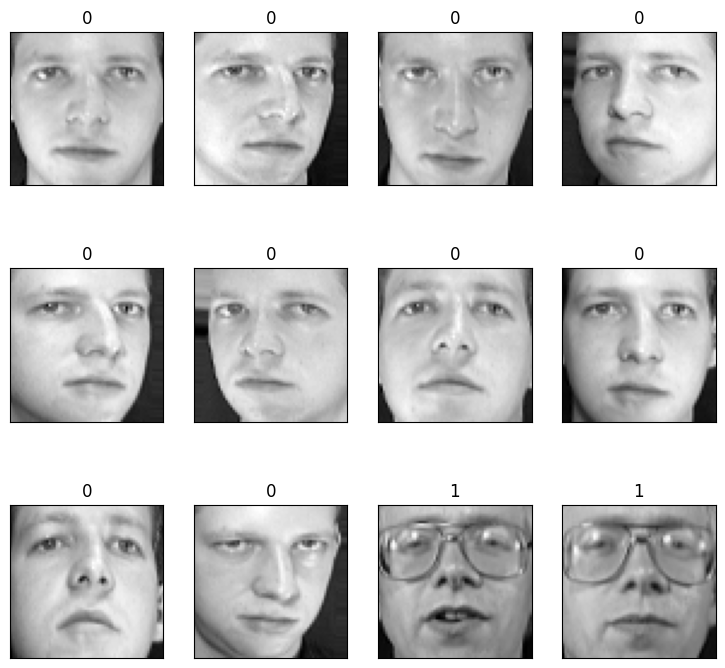

In [ ]:
# Display some images
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

plot_gallery(images, targets, 64, 64)

### <font color='gold'> Task - 2 [Marks 1] </font>:
The dataset consists of 10 images each of 40 people – divide the dataset such that  7 images of each person are in the training set, 1 in the validation set and 2 in the test set (i.e. 70%-10%-20% data split)


In [ ]:
train_idx, val_idx, test_idx = [], [], []
for person in np.unique(targets):
    inds = np.where(targets == person)[0]   # 10 images per person
    # deterministic shuffle for each person
    inds_shuffled = np.random.RandomState(SEED).permutation(inds)
    train_idx.extend(inds_shuffled[:7].tolist())
    val_idx.extend(inds_shuffled[7:8].tolist())
    test_idx.extend(inds_shuffled[8:10].tolist())

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)
test_idx = np.array(test_idx)

In [ ]:
print(f"Train set size: {len(train_idx)}") #280
print(f"Validation set size: {len(val_idx)}") #40
print(f"Test set size: {len(test_idx)}") #80

Train set size: 280
Validation set size: 40
Test set size: 80


### <font color='gold'> Task - 3 [Marks 1] </font>:
Flatten each image 64x64 image of the training set into a 4096-dimensional vector and collect them into a design matrix X of size N x 4096, where N is the size of the training set. Display the dimensions of the newly created matrix.

In [ ]:
# Build flattened datasets
X_train = images[train_idx].reshape(len(train_idx), -1)  # (280, 4096)
y_train = targets[train_idx]
X_val   = images[val_idx].reshape(len(val_idx), -1)      # (40, 4096)
y_val   = targets[val_idx]
X_test  = images[test_idx].reshape(len(test_idx), -1)    # (80, 4096)
y_test  = targets[test_idx]

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (280, 4096)
y_train shape: (280,)
X_val shape: (40, 4096)
y_val shape: (40,)
X_test shape: (80, 4096)
y_test shape: (80,)


### <font color='gold'> Task - 4 [Marks 1] </font>:

Compute the mean image of train, val and test sets and display it.

In [ ]:
def display_image(image, title):
    plt.figure(figsize=(3,3))
    plt.imshow(image.reshape(64,64), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
mean_face_train = np.mean(X_train, axis=0)   # (4096,)
mean_face_val = np.mean(X_val, axis=0)
mean_face_test = np.mean(X_test, axis=0)

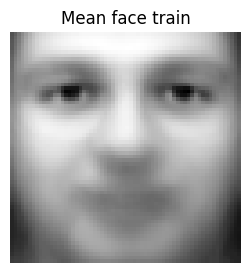

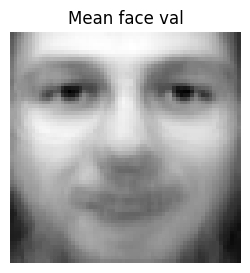

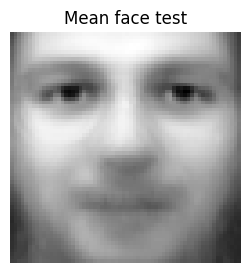

In [ ]:
display_image(mean_face_train, "Mean face train")
display_image(mean_face_val, "Mean face val")
display_image(mean_face_test, "Mean face test")

### <font color='gold'> Task - 5 [Marks 9] </font>:
Perform PCA from scratch on the training set. - 4 Marks

For values

k = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279],

Do the cross validation as described below:


1.   Retain top k Eigen-vectors
2.   Project each mean subtracted training image (using the mean computed at task 4) to the eigenspace to get the k-dimensional feature vector.  Thus, there will be N k-dimensional feature vectors for the training set. - 1 Mark
3.   Project each mean subtracted image (using the mean obtained at task 4) of the validation set to get the k-dimensional feature vectors for the validation image. - 1 Mark
4.   Assign the face id (i.e. persons 1-10) of the validation set by using K-Nearest neighbors (considering the N feature vectors each of k-dimensions on the training set). Use of sklearn's KNN implementation is permitted.
Consider one neighbor for KNN.   - 2 Mark
5.   Compute and report the classification accuracy, i.e. the fraction of the correctly assigned face ids.   - 1 Mark



In [ ]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Compute the covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues and eigenvectors
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Select the top n_components
        self.components = eigenvectors[:, :self.n_components]

    def transform(self, X):
        # Project data onto principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        # Reconstruct original data from principal components
        return np.dot(X_reduced, self.components.T) + self.mean

In [ ]:
# Sanity check
# Initialize and fit PCA
pca_scratch_check = PCAFromScratch(n_components=1000)
pca_scratch_check.fit(X_train)

# Transform the data
X_check = pca_scratch_check.transform(X_train)

In [ ]:
X_check.shape

(280, 1000)

In [ ]:
# #FOR TA USE ONLY#
# #To check for ranges for cross validation#

# # ---- SVD once on mean-centered training data ----
# mean_face = np.mean(X_train, axis=0)
# Xc_train = X_train - mean_face

# print("Computing economy SVD (this is the expensive step).")
# U, S, Vt = np.linalg.svd(Xc_train, full_matrices=False)
# # Vt shape is (r, D) where r = min(N, D). After centering, useful components <= N-1.
# max_k = Vt.shape[0]
# k_max = min(max_k, Xc_train.shape[0]-1)  # conservative: N-1
# print("SVD done. Vt.shape:", Vt.shape, " -> using k_max =", k_max)

# # ---- Precompute full projection matrix once: (N x k_max) ----
# # Vt[:k_max,:] is (k_max x D); Xc_train (N x D) dot (D x k_max) -> (N x k_max)
# X_proj_train_full = Xc_train.dot(Vt[:k_max, :].T)  # (N x k_max)
# # Similarly precompute val and test projections using same Vt
# Xc_val = X_val - mean_face
# X_proj_val_full = Xc_val.dot(Vt[:k_max, :].T)     # (n_val x k_max)
# Xc_test = X_test - mean_face
# X_proj_test_full = Xc_test.dot(Vt[:k_max, :].T)   # (n_test x k_max)

# # ---- Define knn list and k range ----
# k_range = list(range(1, k_max+1))   # 1..k_max (e.g., 1..279)
# knn_list = [1,3,5,7,9,11]           # choose odd K to avoid ties

# # ---- Evaluate accuracies for every (k, K_nn) ----
# # results matrix: rows -> k index (1..k_max), cols -> knn choices
# results = np.zeros((len(k_range), len(knn_list)), dtype=float)

# for i, k in enumerate(k_range):
#     # select first k components (columns) from precomputed projections
#     train_proj_k = X_proj_train_full[:, :k]   # (N x k)
#     val_proj_k   = X_proj_val_full[:, :k]     # (n_val x k)
#     for j, K_nn in enumerate(knn_list):
#         knn = KNeighborsClassifier(n_neighbors=K_nn)
#         knn.fit(train_proj_k, y_train)
#         preds = knn.predict(val_proj_k)
#         results[i, j] = accuracy_score(y_val, preds)

# # ---- Find best (k, K_nn) using tie-break: highest acc, smallest k, smallest K_nn ----
# best_idx = np.argwhere(results == results.max())
# # best_idx is a list of (i,j) with equal top accuracy
# # convert to list of tuples and sort by (k asc, K_nn asc)
# best_candidates = [(i+1, knn_list[j], results[i,j]) for (i,j) in best_idx]
# best_candidates_sorted = sorted(best_candidates, key=lambda t: (t[0], t[1]))  # sort by k then K
# best_k, best_K_nn, best_acc = best_candidates_sorted[0]
# print(f"Best validation pair (tie-broken): k={best_k}, K_nn={best_K_nn}, val_acc={best_acc:.4f}")

# # ---- Plot: one curve per K_nn ----
# plt.figure(figsize=(11,5))
# for j, K_nn in enumerate(knn_list):
#     plt.plot(k_range, results[:, j], label=f"K={K_nn}", linewidth=1)
# plt.scatter([best_k], [best_acc], color='red', s=100, zorder=5, label=f'Best (k={best_k},K={best_K_nn})')
# plt.xlabel("k (number of eigenfaces)")
# plt.ylabel("Validation accuracy")
# plt.title("Validation accuracy vs k for different K (full k=1..k_max)")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.xlim(1, k_max)
# plt.show()

# # ---- Print top results (k, K_nn, acc) sorted ----
# flat_results = []
# for i,k in enumerate(k_range):
#     for j,K_nn in enumerate(knn_list):
#         flat_results.append((k, K_nn, results[i,j]))
# flat_results_sorted = sorted(flat_results, key=lambda t: (-t[2], t[0], t[1]))  # best acc, smaller k, smaller K
# print("Top 10 (k, K_nn, val_acc):")
# for item in flat_results_sorted[:10]:
#     print(f"  k={item[0]:3d}, K={item[1]:2d} -> acc={item[2]:.4f}")

# # ---- Optional: evaluate chosen pair on test set ----
# train_proj_best = X_proj_train_full[:, :best_k]
# test_proj_best = X_proj_test_full[:, :best_k]
# knn_best = KNeighborsClassifier(n_neighbors=best_K_nn)
# knn_best.fit(train_proj_best, y_train)
# test_acc = accuracy_score(y_test, knn_best.predict(test_proj_best))
# print("Test accuracy for chosen pair (k, K_nn):", test_acc)

In [ ]:
# Supplied values of K
K_values = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]

In [ ]:
accuracies = {}
for k in K_values:
    pca_full = PCAFromScratch(n_components=k)
    pca_full.fit(X_train)
    train_proj = pca_full.transform(X_train)
    val_proj   = pca_full.transform(X_val)
    knn = KNeighborsClassifier(n_neighbors=1)   # per assignment: use 1 neighbor
    knn.fit(train_proj, y_train)
    preds = knn.predict(val_proj)
    acc = accuracy_score(y_val, preds)
    accuracies[k] = acc
    print(f"k={k:3d} -> val acc = {acc:.4f}")

k=  5 -> val acc = 0.6250
k= 10 -> val acc = 0.8500
k= 15 -> val acc = 0.9000
k= 20 -> val acc = 0.9250
k= 25 -> val acc = 0.9500
k= 30 -> val acc = 0.9500
k= 40 -> val acc = 0.9500
k= 50 -> val acc = 0.9500
k= 75 -> val acc = 0.9500
k=100 -> val acc = 0.9500
k=150 -> val acc = 0.9500
k=200 -> val acc = 0.9500
k=279 -> val acc = 0.9500


### <font color='gold'> Task - 6 [Marks 1] </font>:
Plot the accuracy as a function of k.

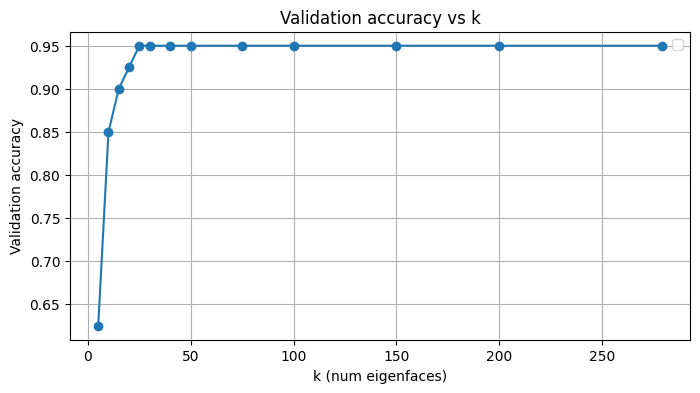

In [ ]:
plot_k = sorted(accuracies.keys())
plot_acc = [accuracies[k] for k in plot_k]

plt.figure(figsize=(8,4))
plt.plot(plot_k, plot_acc, marker='o')
plt.xlabel('k (num eigenfaces)')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy vs k')
plt.grid(True)
plt.legend()
plt.show()

### <font color='gold'> Task - 7 [Marks 1] </font>:
Pick and report a value of k that gives good tradeoff between accuracy and number of eigen vectors used. (Tie breaking - For the same accuracy, report the lowest k value)

In [ ]:
# Pick chosen_k from accuracies dict
best_val_acc = max(accuracies.values())
best_k_candidates = [k for k, acc in accuracies.items() if acc == best_val_acc]
chosen_k = min(best_k_candidates)  # tie-break by smallest k

print(f"Chosen k = {chosen_k}, best val acc = {best_val_acc:.4f}")

Chosen k = 25, best val acc = 0.9500


### <font color='gold'> Task - 8 [Marks 2] </font>:
Visualize the k eigen vectors as eigenfaces for the chosen value of k.

Principal components in the decreasing order of eigen values: 


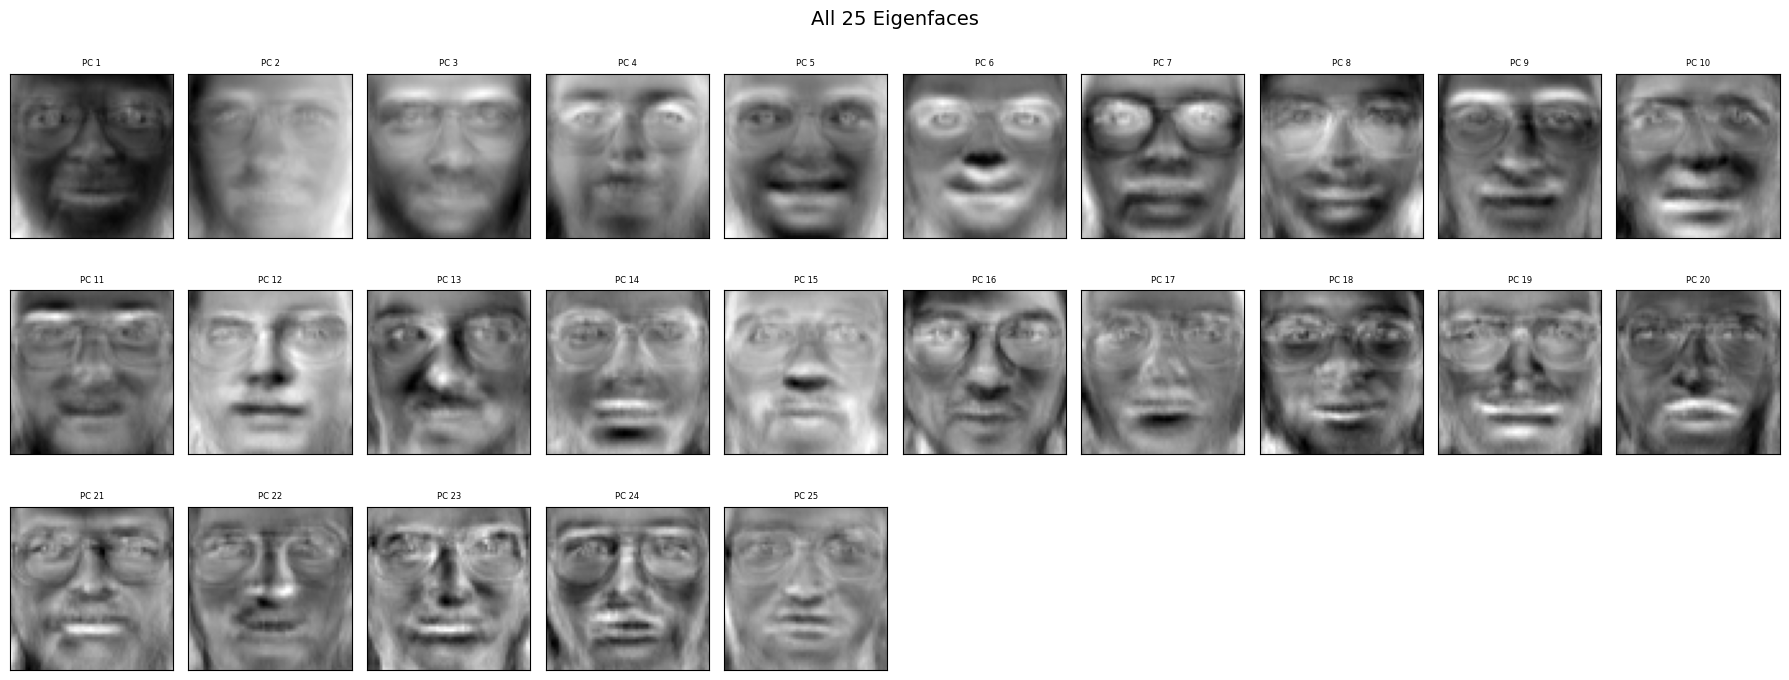

In [ ]:
pca_chosen = PCAFromScratch(n_components=chosen_k)
pca_chosen.fit(X_train)

# eigenfaces (principal components)
eigenfaces = pca_chosen.components  # shape (4096, chosen_k)

def plot_all_eigenfaces(images, h=64, w=64, title="Eigenfaces"):
    n_components = images.shape[1]
    n_col = 10  # fix number of columns
    n_row = int(np.ceil(n_components / n_col))

    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.suptitle(title, fontsize=14)

    print("Principal components in the decreasing order of eigen values: ")

    for i in range(n_components):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[:, i].reshape((h, w)), cmap=plt.cm.gray)
        plt.xticks(())
        plt.yticks(())
        plt.title(f"PC {i+1}", fontsize=6)

    plt.tight_layout()
    plt.show()

plot_all_eigenfaces(eigenfaces, title=f"All {chosen_k} Eigenfaces")

### <font color='gold'> Task - 9 [Marks 1] </font>:
For the chosen value of k, report the classification accuracy on the test set using K-NN based classification as described for the validation set.  

In [ ]:
train_proj = pca_chosen.transform(X_train)
test_proj  = pca_chosen.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(train_proj, y_train)
test_preds = knn.predict(test_proj)
test_acc = accuracy_score(y_test, test_preds)

print(f"Test accuracy with k={chosen_k} eigenfaces = {test_acc:.4f}")

Test accuracy with k=25 eigenfaces = 0.8750


### <font color='gold'> Task - 10 [Marks 2] </font>:
For the chosen value of k, perform PCA using scikit-learn, and report the classification accuracy on the test set. Compare the performance with the from scratch implementation.  

In [ ]:
sk_pca = SKPCA(n_components=chosen_k, whiten=False, random_state=SEED)
sk_pca.fit(X_train)

# Project data
train_proj_sk = sk_pca.transform(X_train)
val_proj_sk   = sk_pca.transform(X_val)
test_proj_sk  = sk_pca.transform(X_test)

# Train KNN
knn_sk = KNeighborsClassifier(n_neighbors=1)
knn_sk.fit(train_proj_sk, y_train)

# Predictions
val_preds_sk   = knn_sk.predict(val_proj_sk)
test_preds_sk  = knn_sk.predict(test_proj_sk)

# Accuracies
val_acc_sk   = accuracy_score(y_val, val_preds_sk)
test_acc_sk  = accuracy_score(y_test, test_preds_sk)

print(f"Val   accuracy with sklearn PCA (k={chosen_k}) = {val_acc_sk:.4f}")
print(f"Test  accuracy with sklearn PCA (k={chosen_k}) = {test_acc_sk:.4f}")

Val   accuracy with sklearn PCA (k=25) = 0.9500
Test  accuracy with sklearn PCA (k=25) = 0.8750


In [ ]:
results_table = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "Scratch PCA": [best_val_acc, test_acc],
    "sklearn PCA": [val_acc_sk, test_acc_sk]
})

print(results_table.to_string(index=False))

   Dataset  Scratch PCA  sklearn PCA
Validation        0.950        0.950
      Test        0.875        0.875


Similar values